# Section 6 v2 — Sentiment rebuild: domain scoring, high-frequency attention, scorer validation

Thin driver notebook: all logic lives in `src/sentiment/`. Supersedes the original Section 6 notebook's alarm index (kept in place at `notebooks/6_sentiment.ipynb` for reference) with three fixes made *before* any new data was added, per the build brief:

1. **Domain scoring, not VADER.** The original index used VADER (social-media-tuned valence), which barely fires on regulator prose, and was multiplicative (`mentions x negativity`), which zeroes out any report with heavy coverage but non-negative measured tone. The rebuilt index (`src/sentiment/scoring.py`, `analysis_alarm_v2.py`) is additive and z-scored within institution, using Loughran-McDonald negative/uncertainty rates plus a hand-curated vulnerability lexicon (`config.VULNERABILITY_STEMS`). Result: **37 of 40 reports scored exactly zero under the old index; the rebuilt index has real variation across all of them** (see the ledger below).
2. **The LM master dictionary download, previously blocked, is resolved.** The SRAF landing page links a Google Drive share, not a client-rendered file (`src/common/text.py:fetch_lm_dictionary`) — discovered by re-reading the actual page source, not re-assuming the earlier finding.
3. **A second, independent scorer** (a fixed-prompt LLM rubric, temperature 0, cached by input hash — same stub pattern as `src/common/entity.py`'s `llm_tiebreak_cached`) cross-validates a hand-scored sample of sections (`analysis_scorer_validation.py`).

**New corpora**: Bank of England Financial Stability Reports (`scrape_regulators_v2.py`) join the existing Fed/BIS/ECB corpus. Google News RSS + yfinance ticker news (`scrape_news_rss.py`, `scrape_yf_news.py`) form a headline-based attention/tone backbone, standing in for **GDELT**, which is fully implemented (`scrape_gdelt.py`) but persistently rate-limited (HTTP 429) from this project's sandboxed network even with full exponential backoff — logged in `docs/excluded_sources.md`, not silently worked around. The same headline corpus is classified for CLO new-issue pricing announcements (`scrape_pressreleases.py`).

**Not implemented this pass** (documented gaps, not silent drops): FSOC/OFR annual reports, congressional testimony (govinfo.gov), Fed/BoE speech archives, conference-agenda topic drift, podcast corpora, SSRN/RePEc (arXiv only). See `docs/excluded_sources.md`.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

from IPython.display import Image, display

from src.sentiment import (
    scrape_regulators_v2, scrape_gdelt, scrape_news_rss, scrape_yf_news, scrape_pressreleases,
    scrape_stocktwits, scrape_ssrn_arxiv,
    scoring, analysis_alarm_v2, analysis_attention_tone, analysis_scorer_validation,
    viz_alarm_v2, viz_attention, viz_validation,
    ledger,
)


/Users/zinuoshi/clo-atlas/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Scrape (raw -> interim)

In [2]:
RUN_SCRAPE = False
if RUN_SCRAPE:
    scrape_regulators_v2.run()   # Bank of England FSRs
    scrape_gdelt.run()           # rate-limited from this environment; degrades gracefully
    scrape_news_rss.run()
    scrape_yf_news.run()
    scrape_pressreleases.run()   # classifies news_headlines.parquet, no new network calls
    scrape_stocktwits.run()
    scrape_ssrn_arxiv.run()


## Analysis (interim -> final)

In [3]:
alarm_v2 = analysis_alarm_v2.run()
attention_tone = analysis_attention_tone.run()
scorer_validation = analysis_scorer_validation.run()


## Viz (final -> figures/)

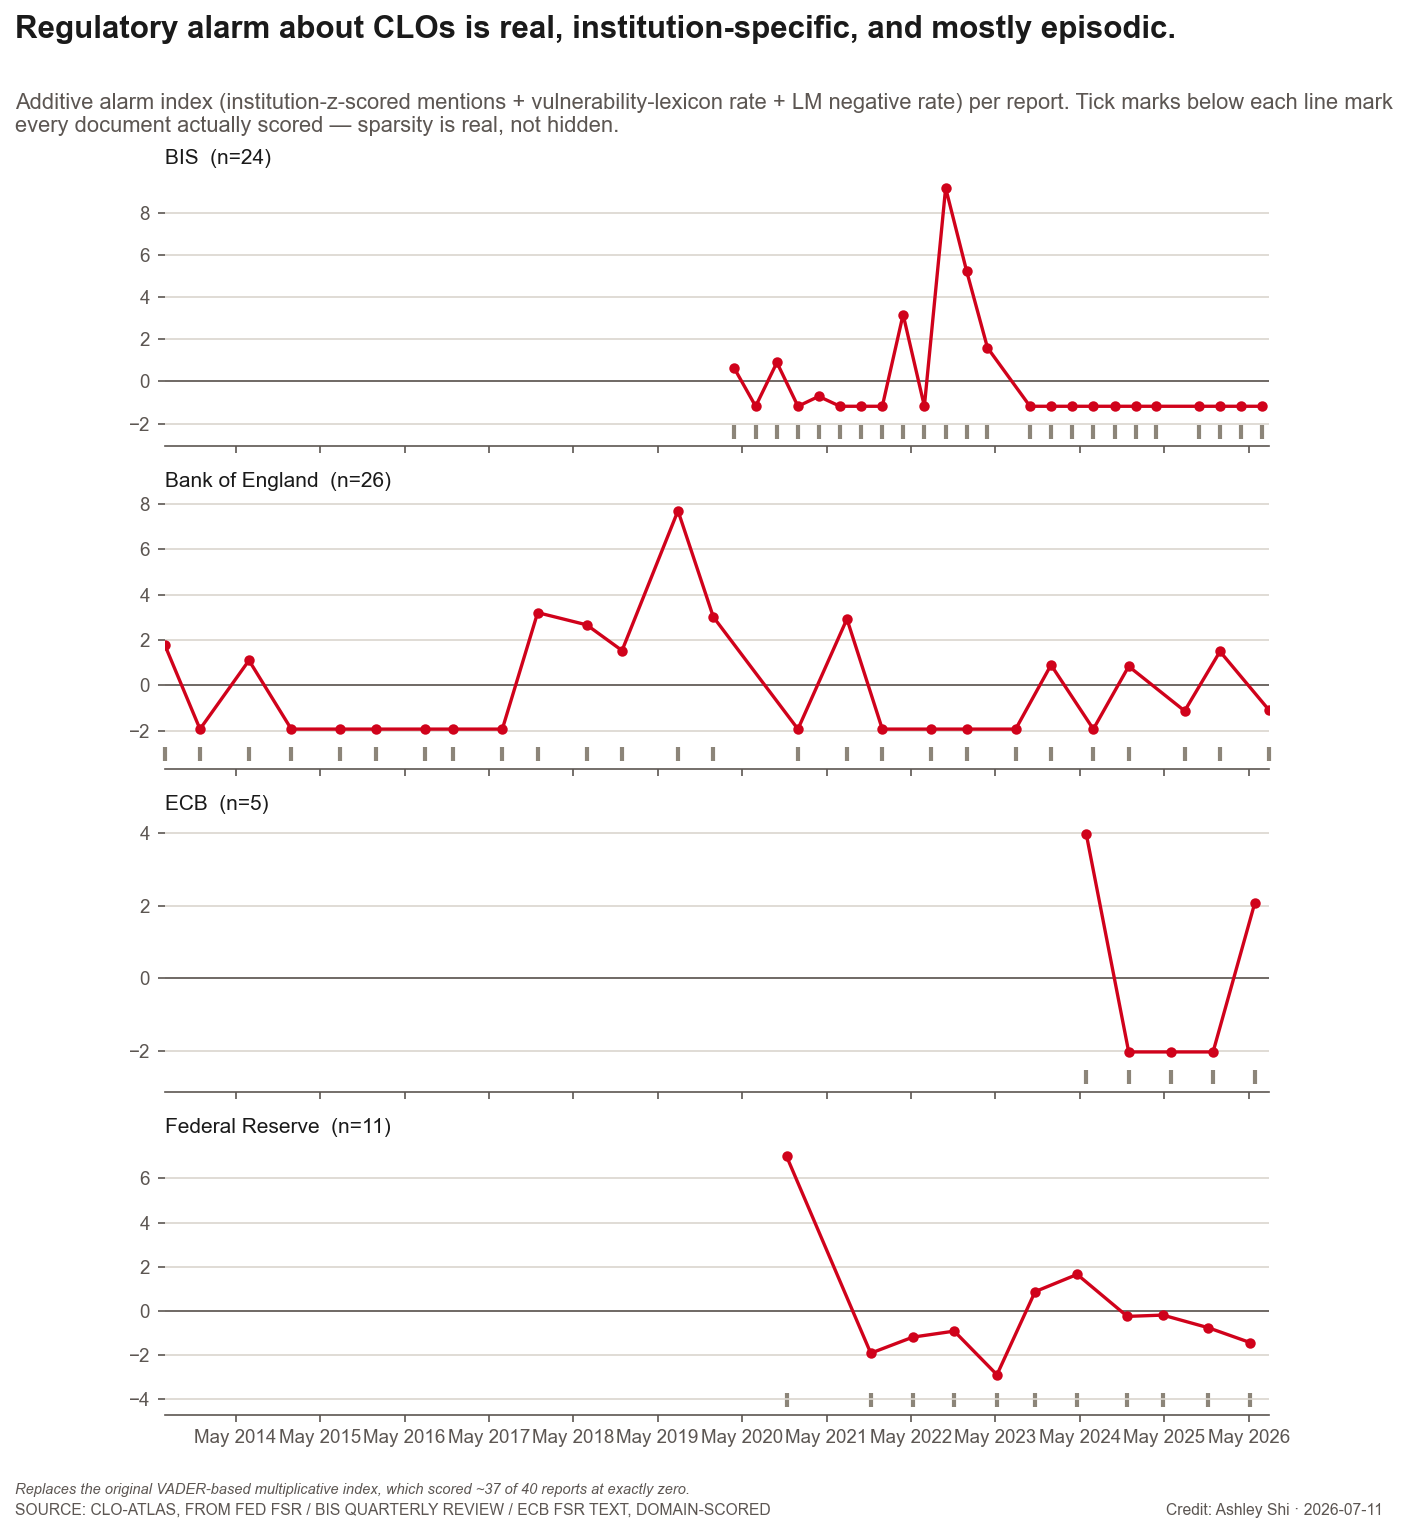

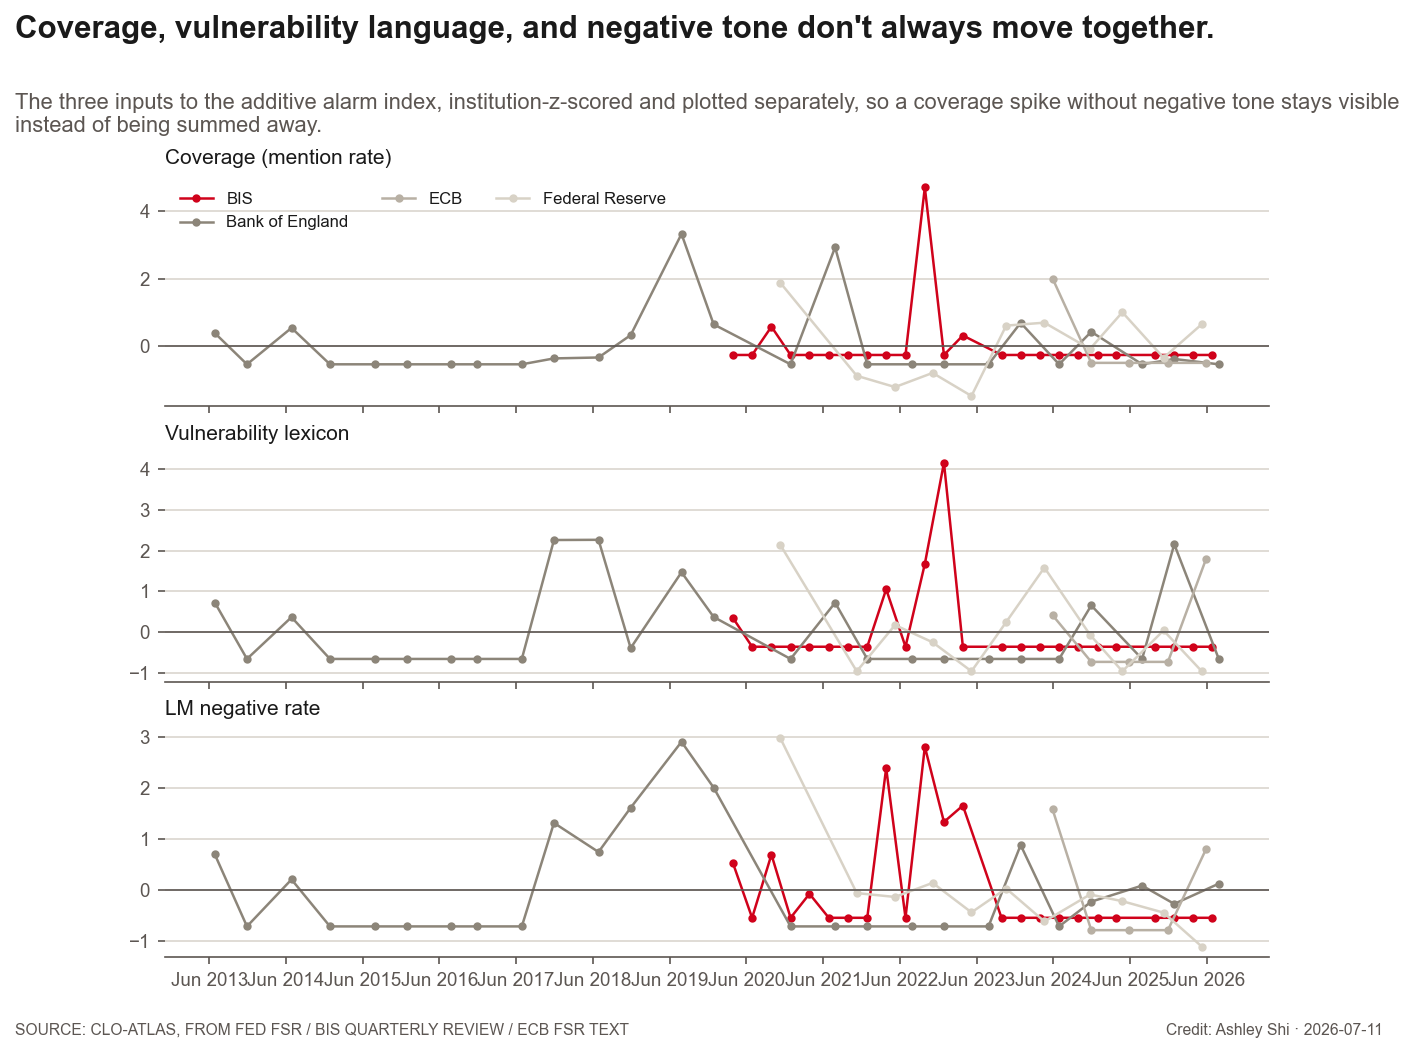

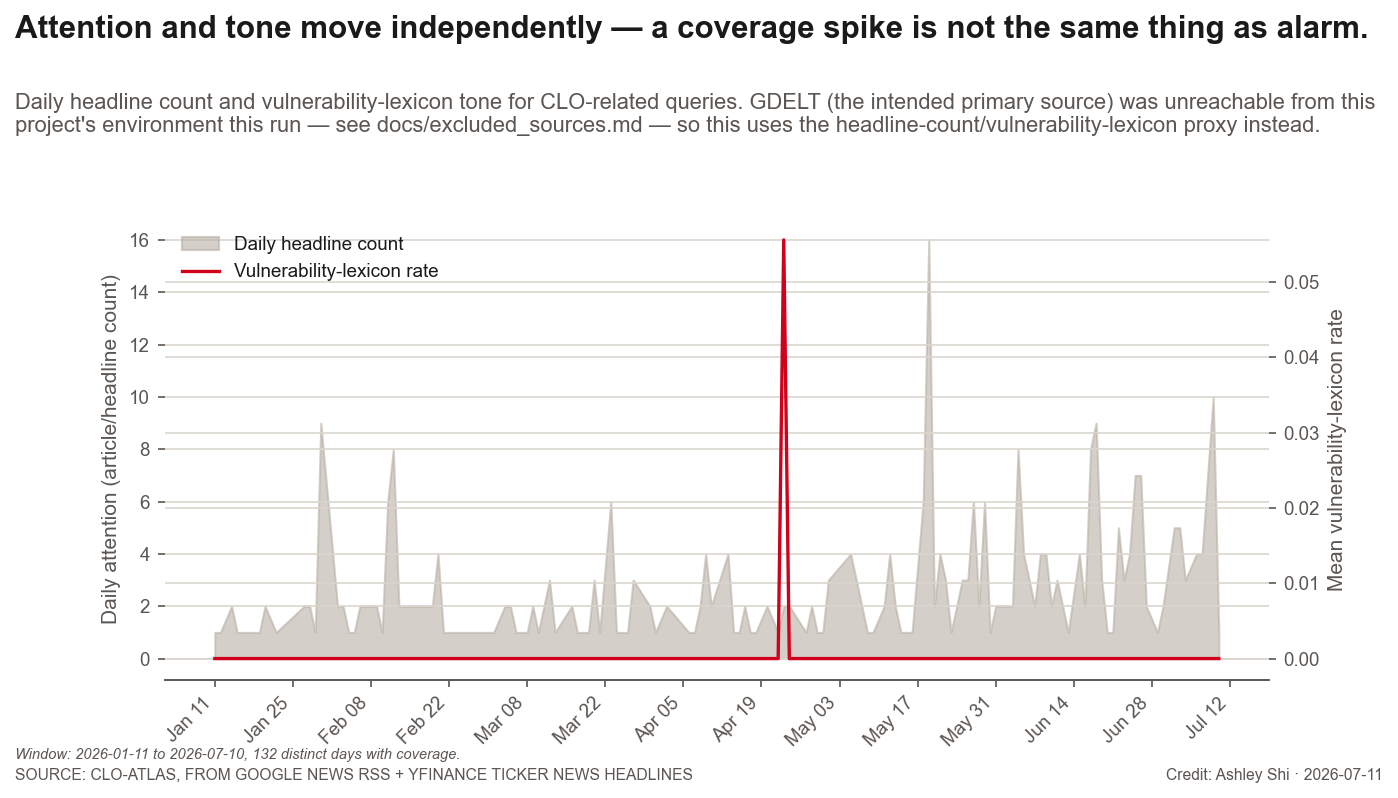

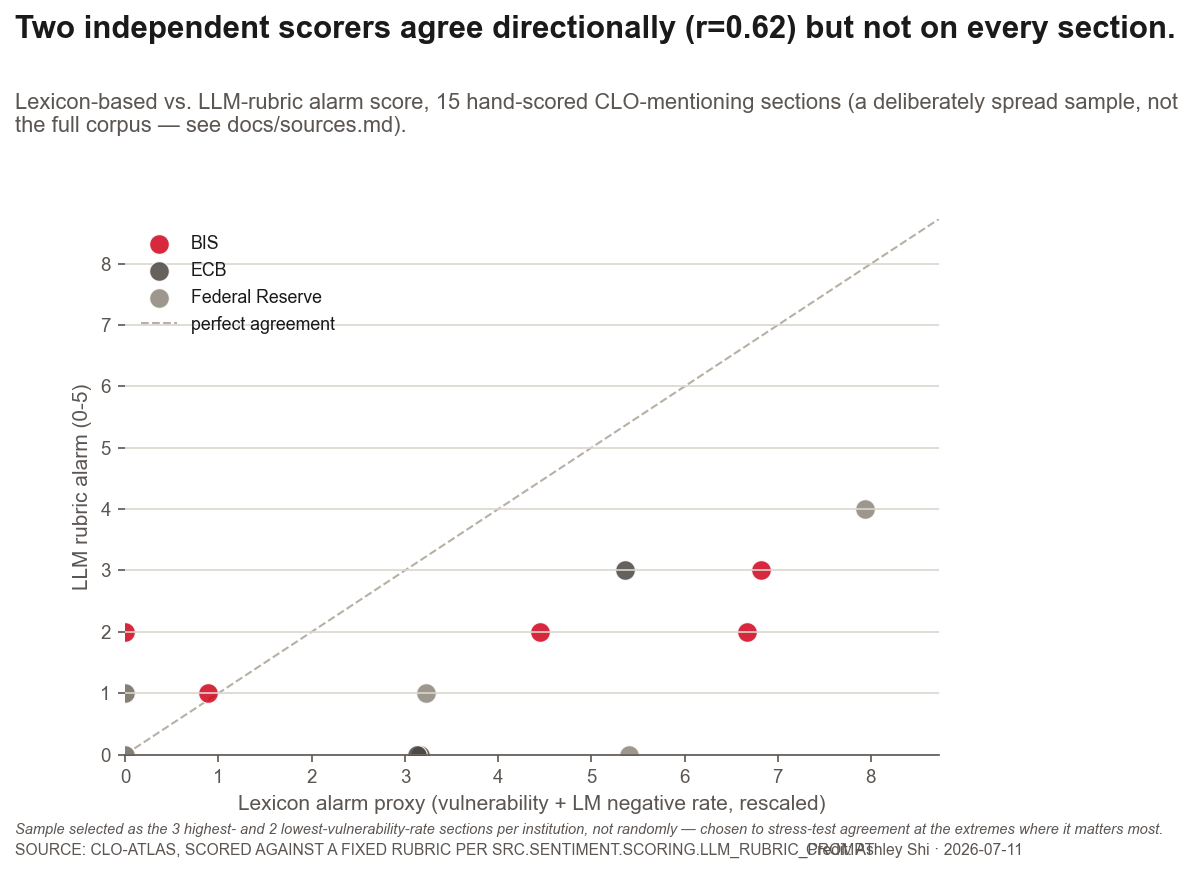

In [4]:
viz_alarm_v2.run()
viz_attention.run()
viz_validation.run()


## Exhibits

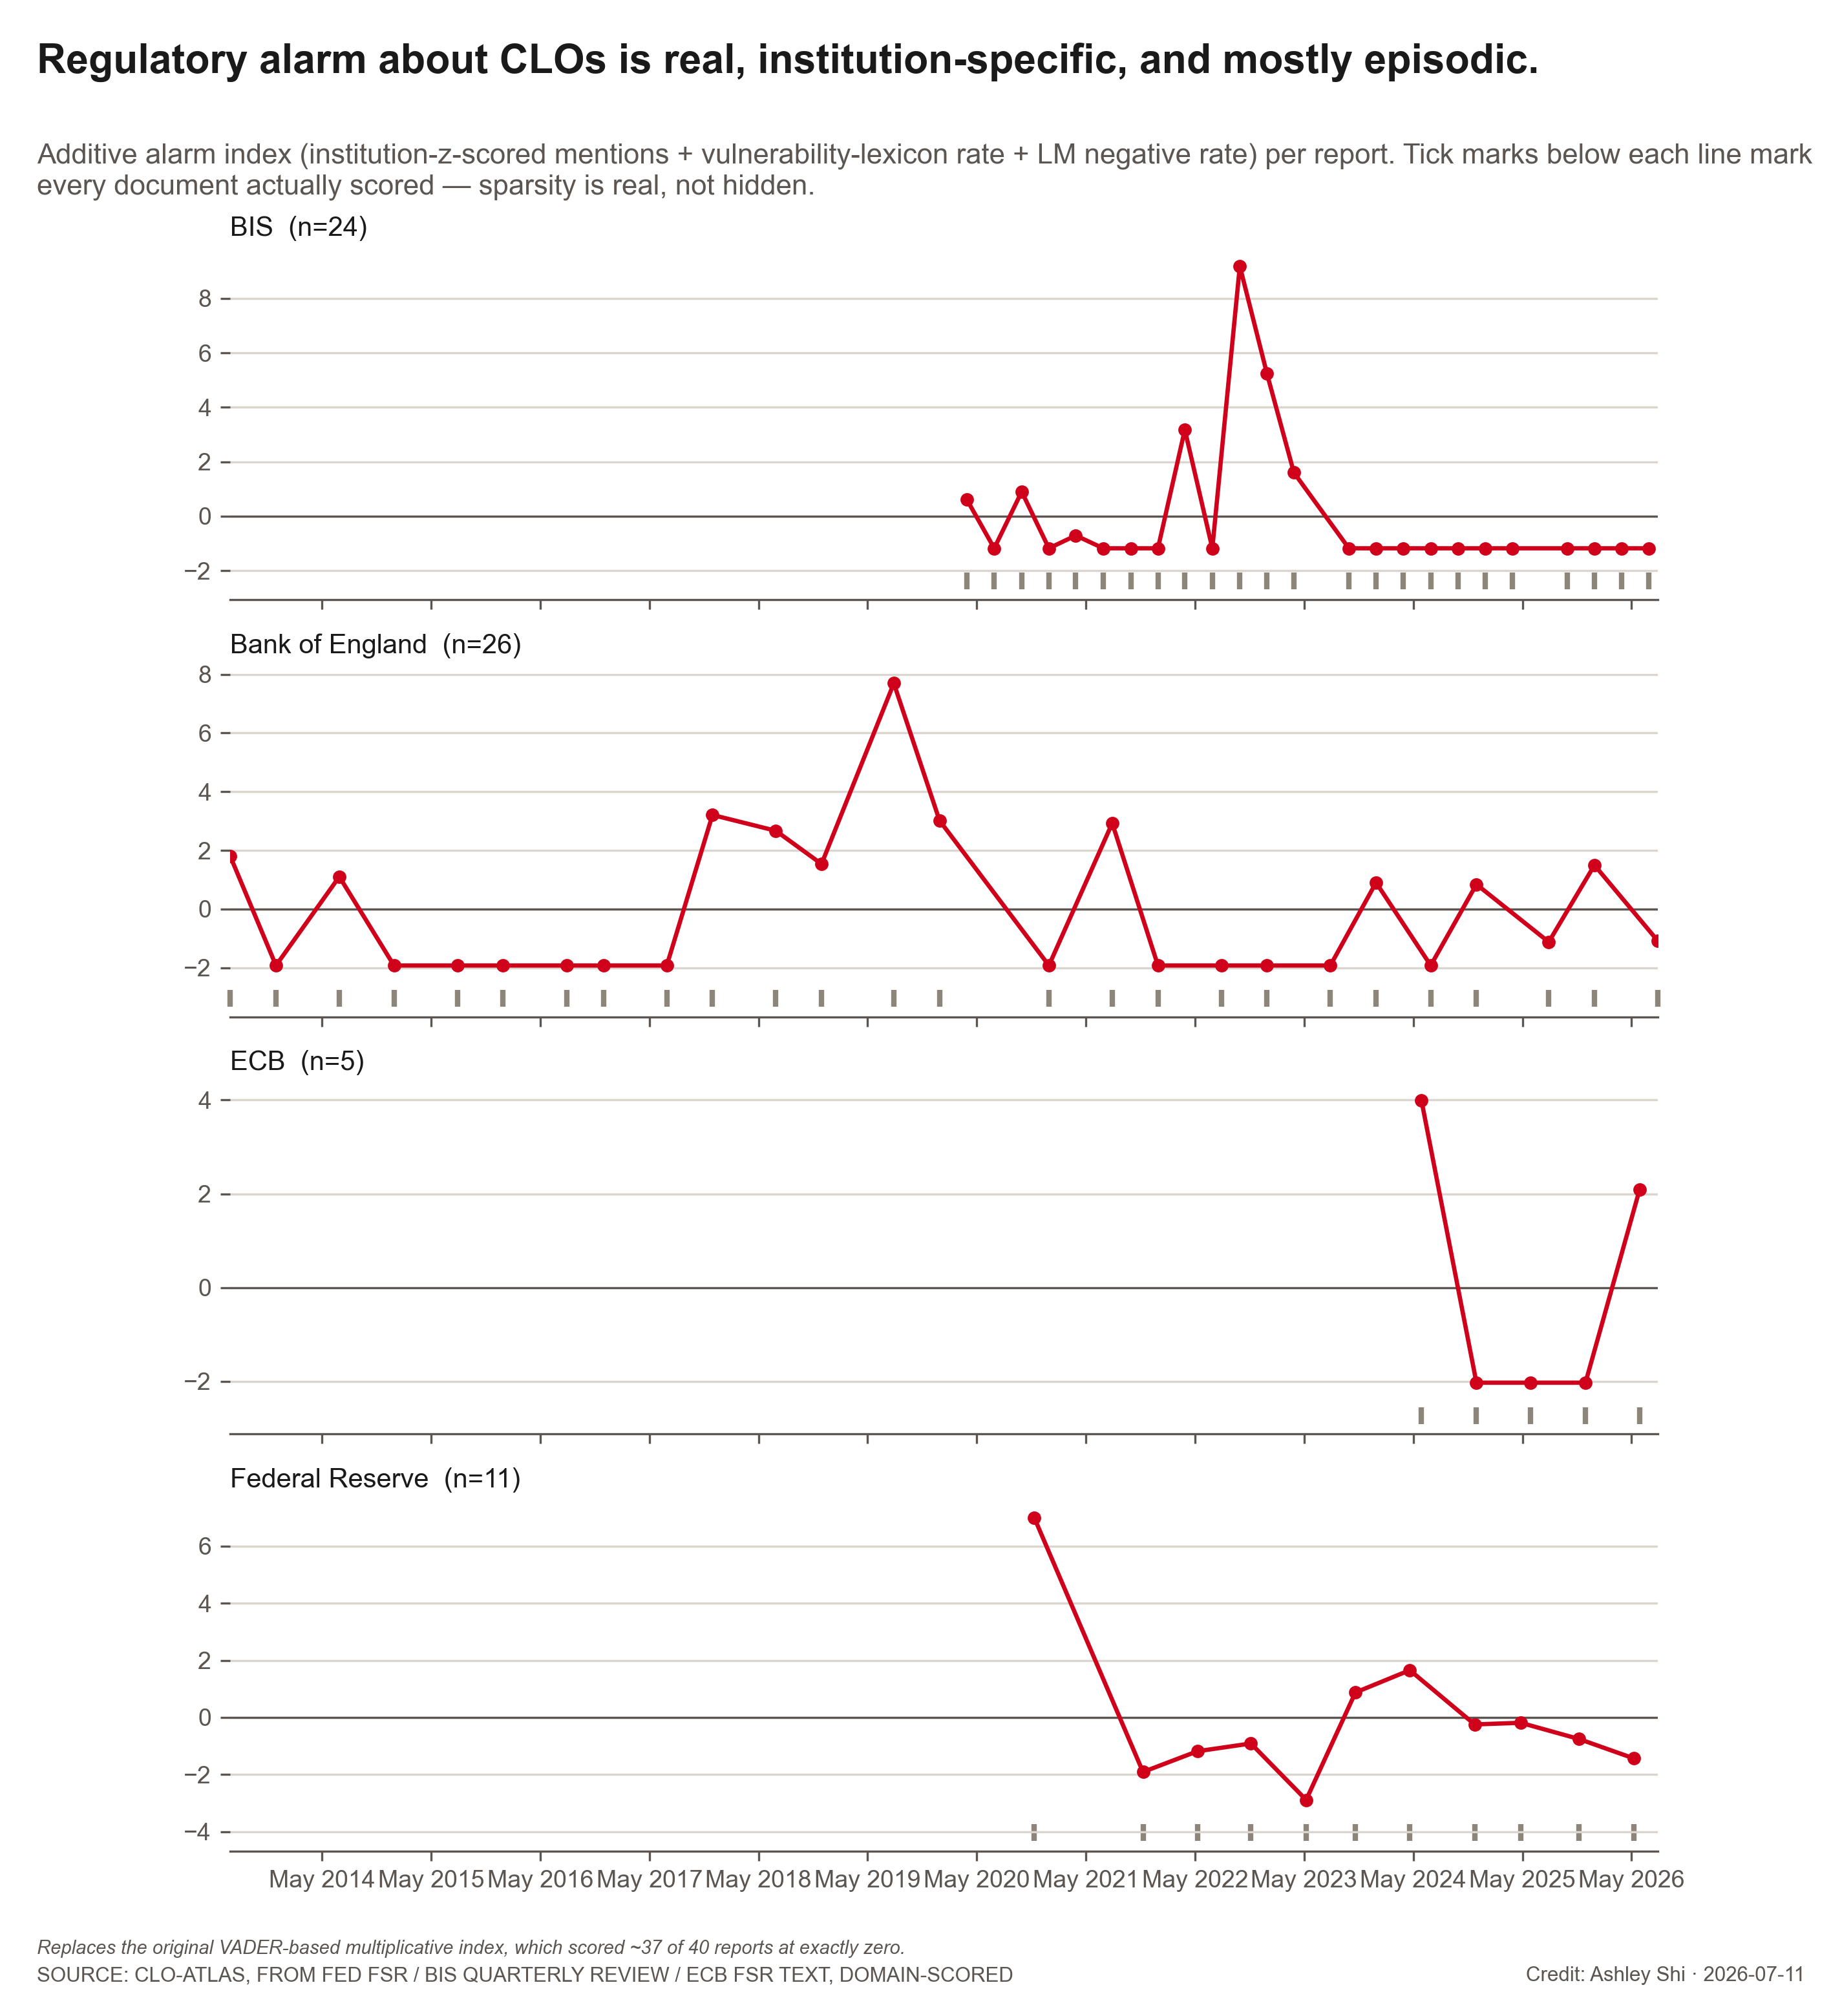

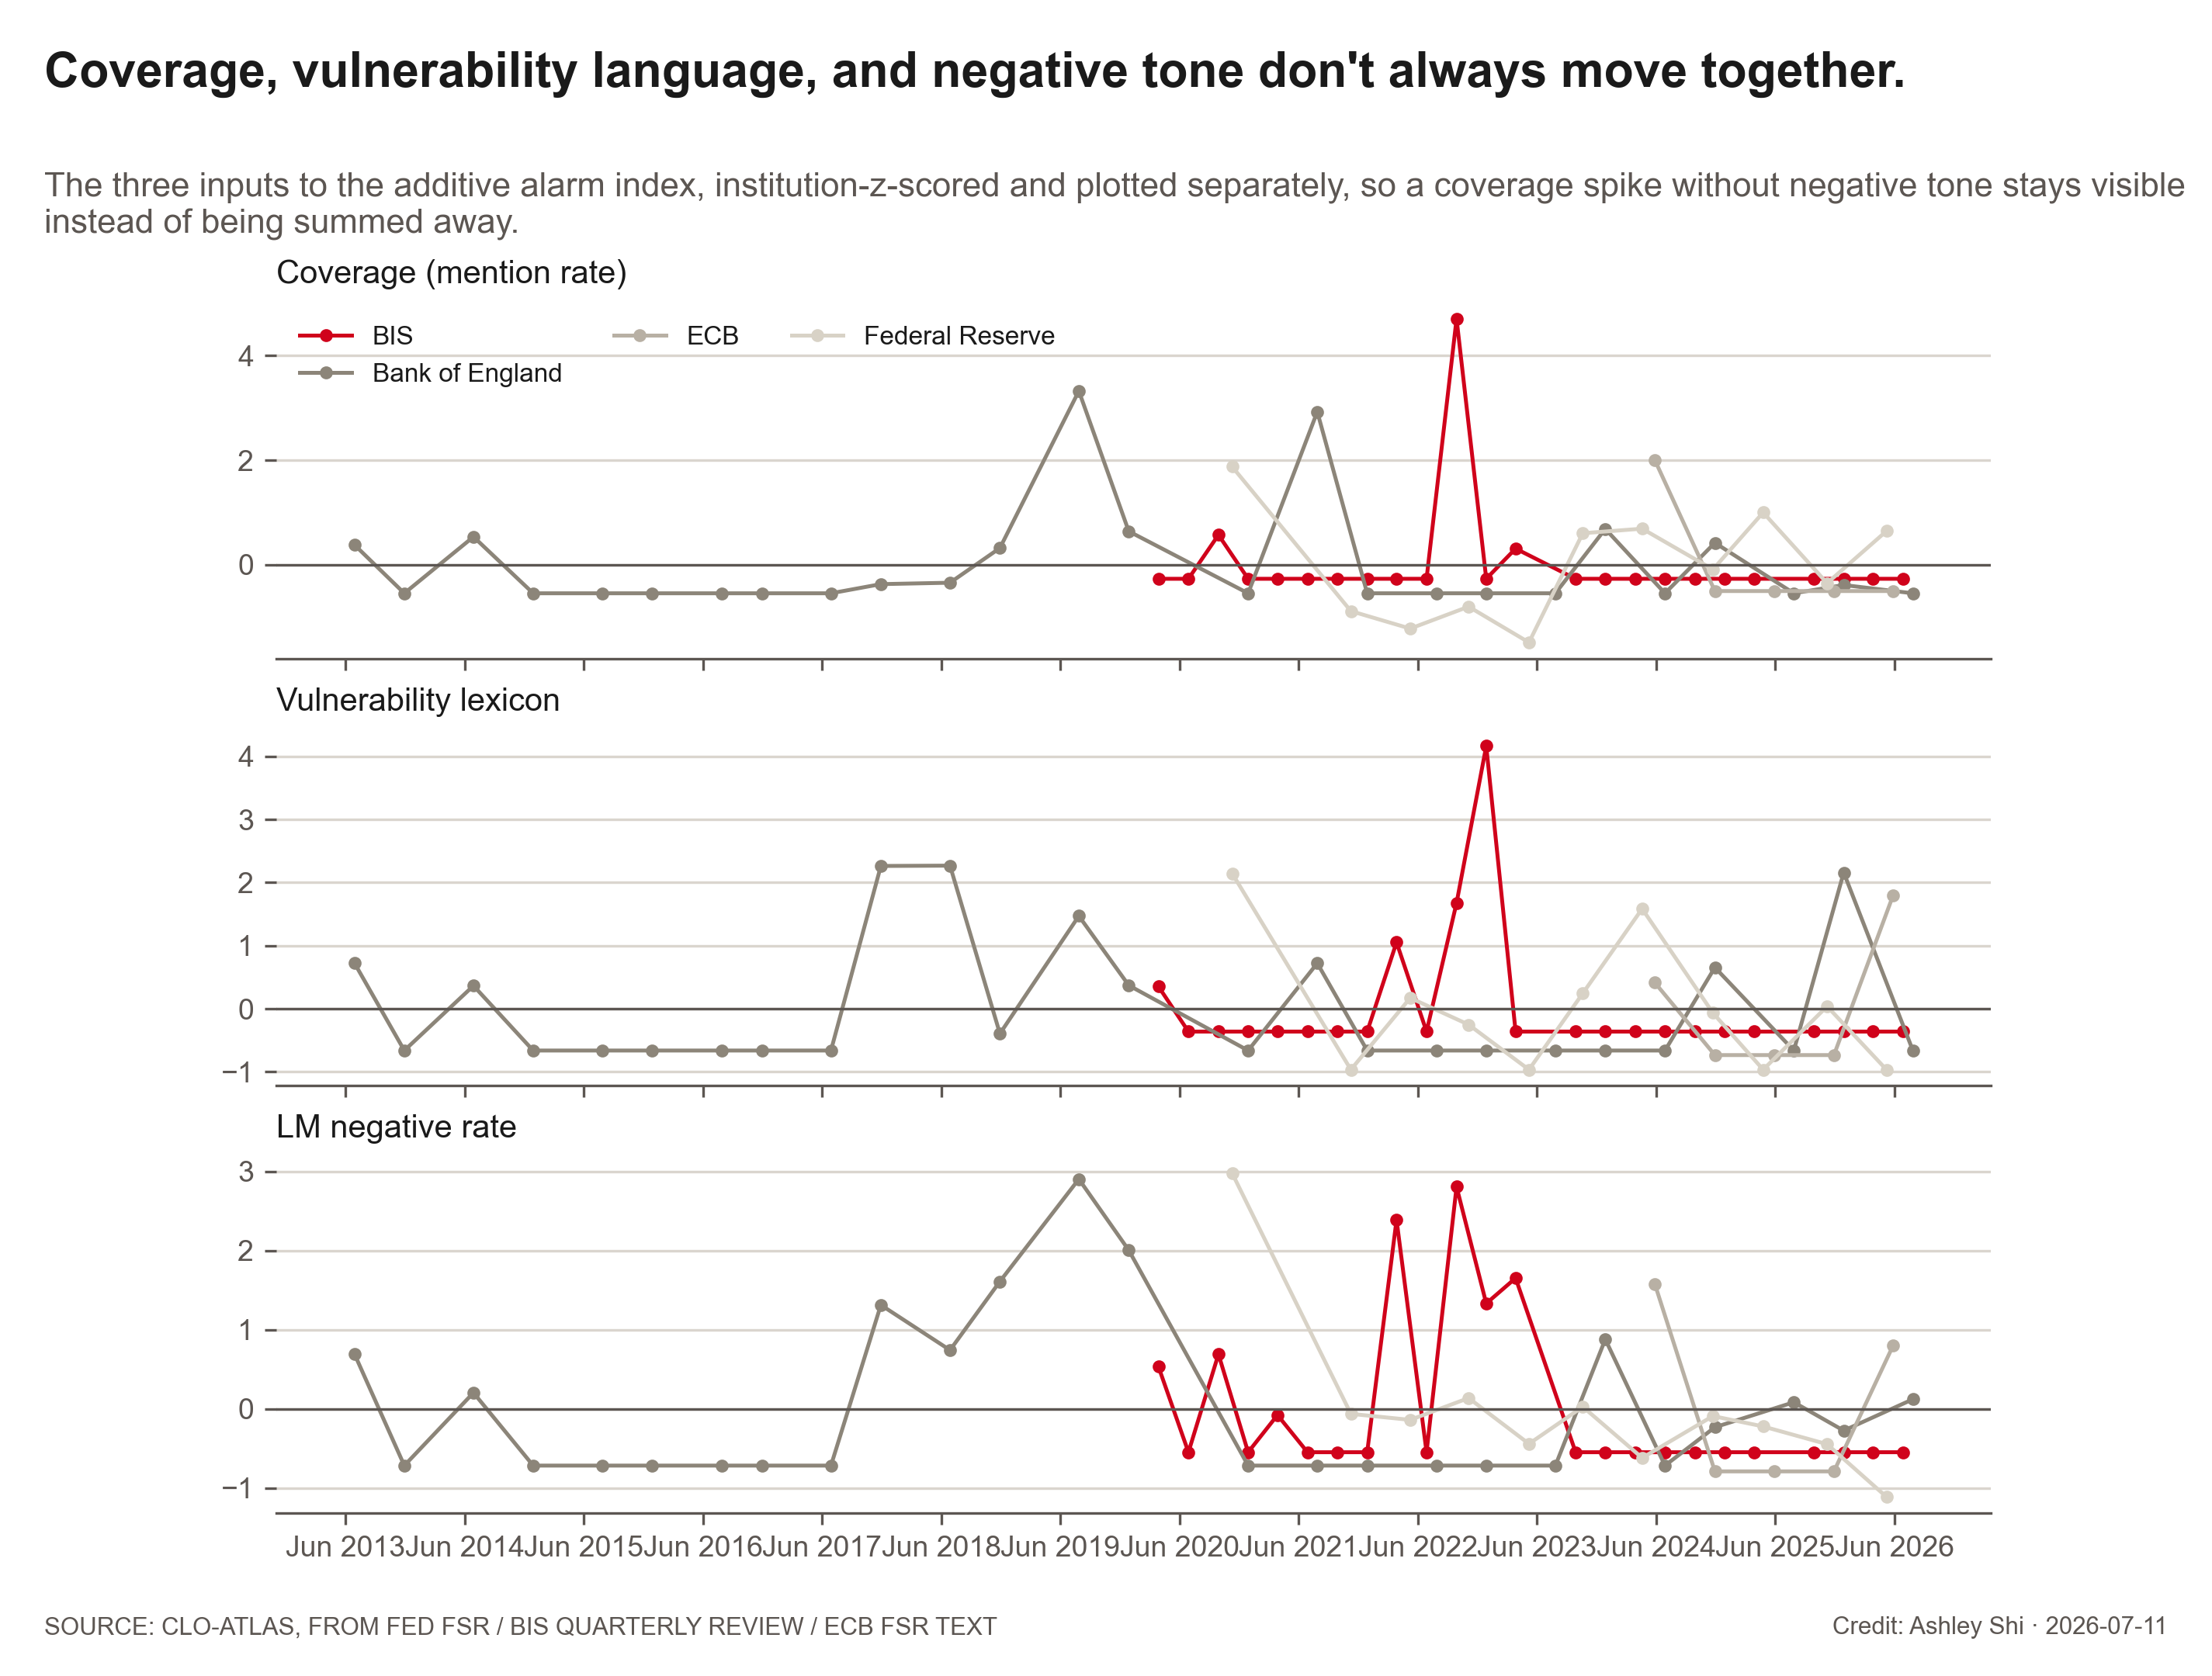

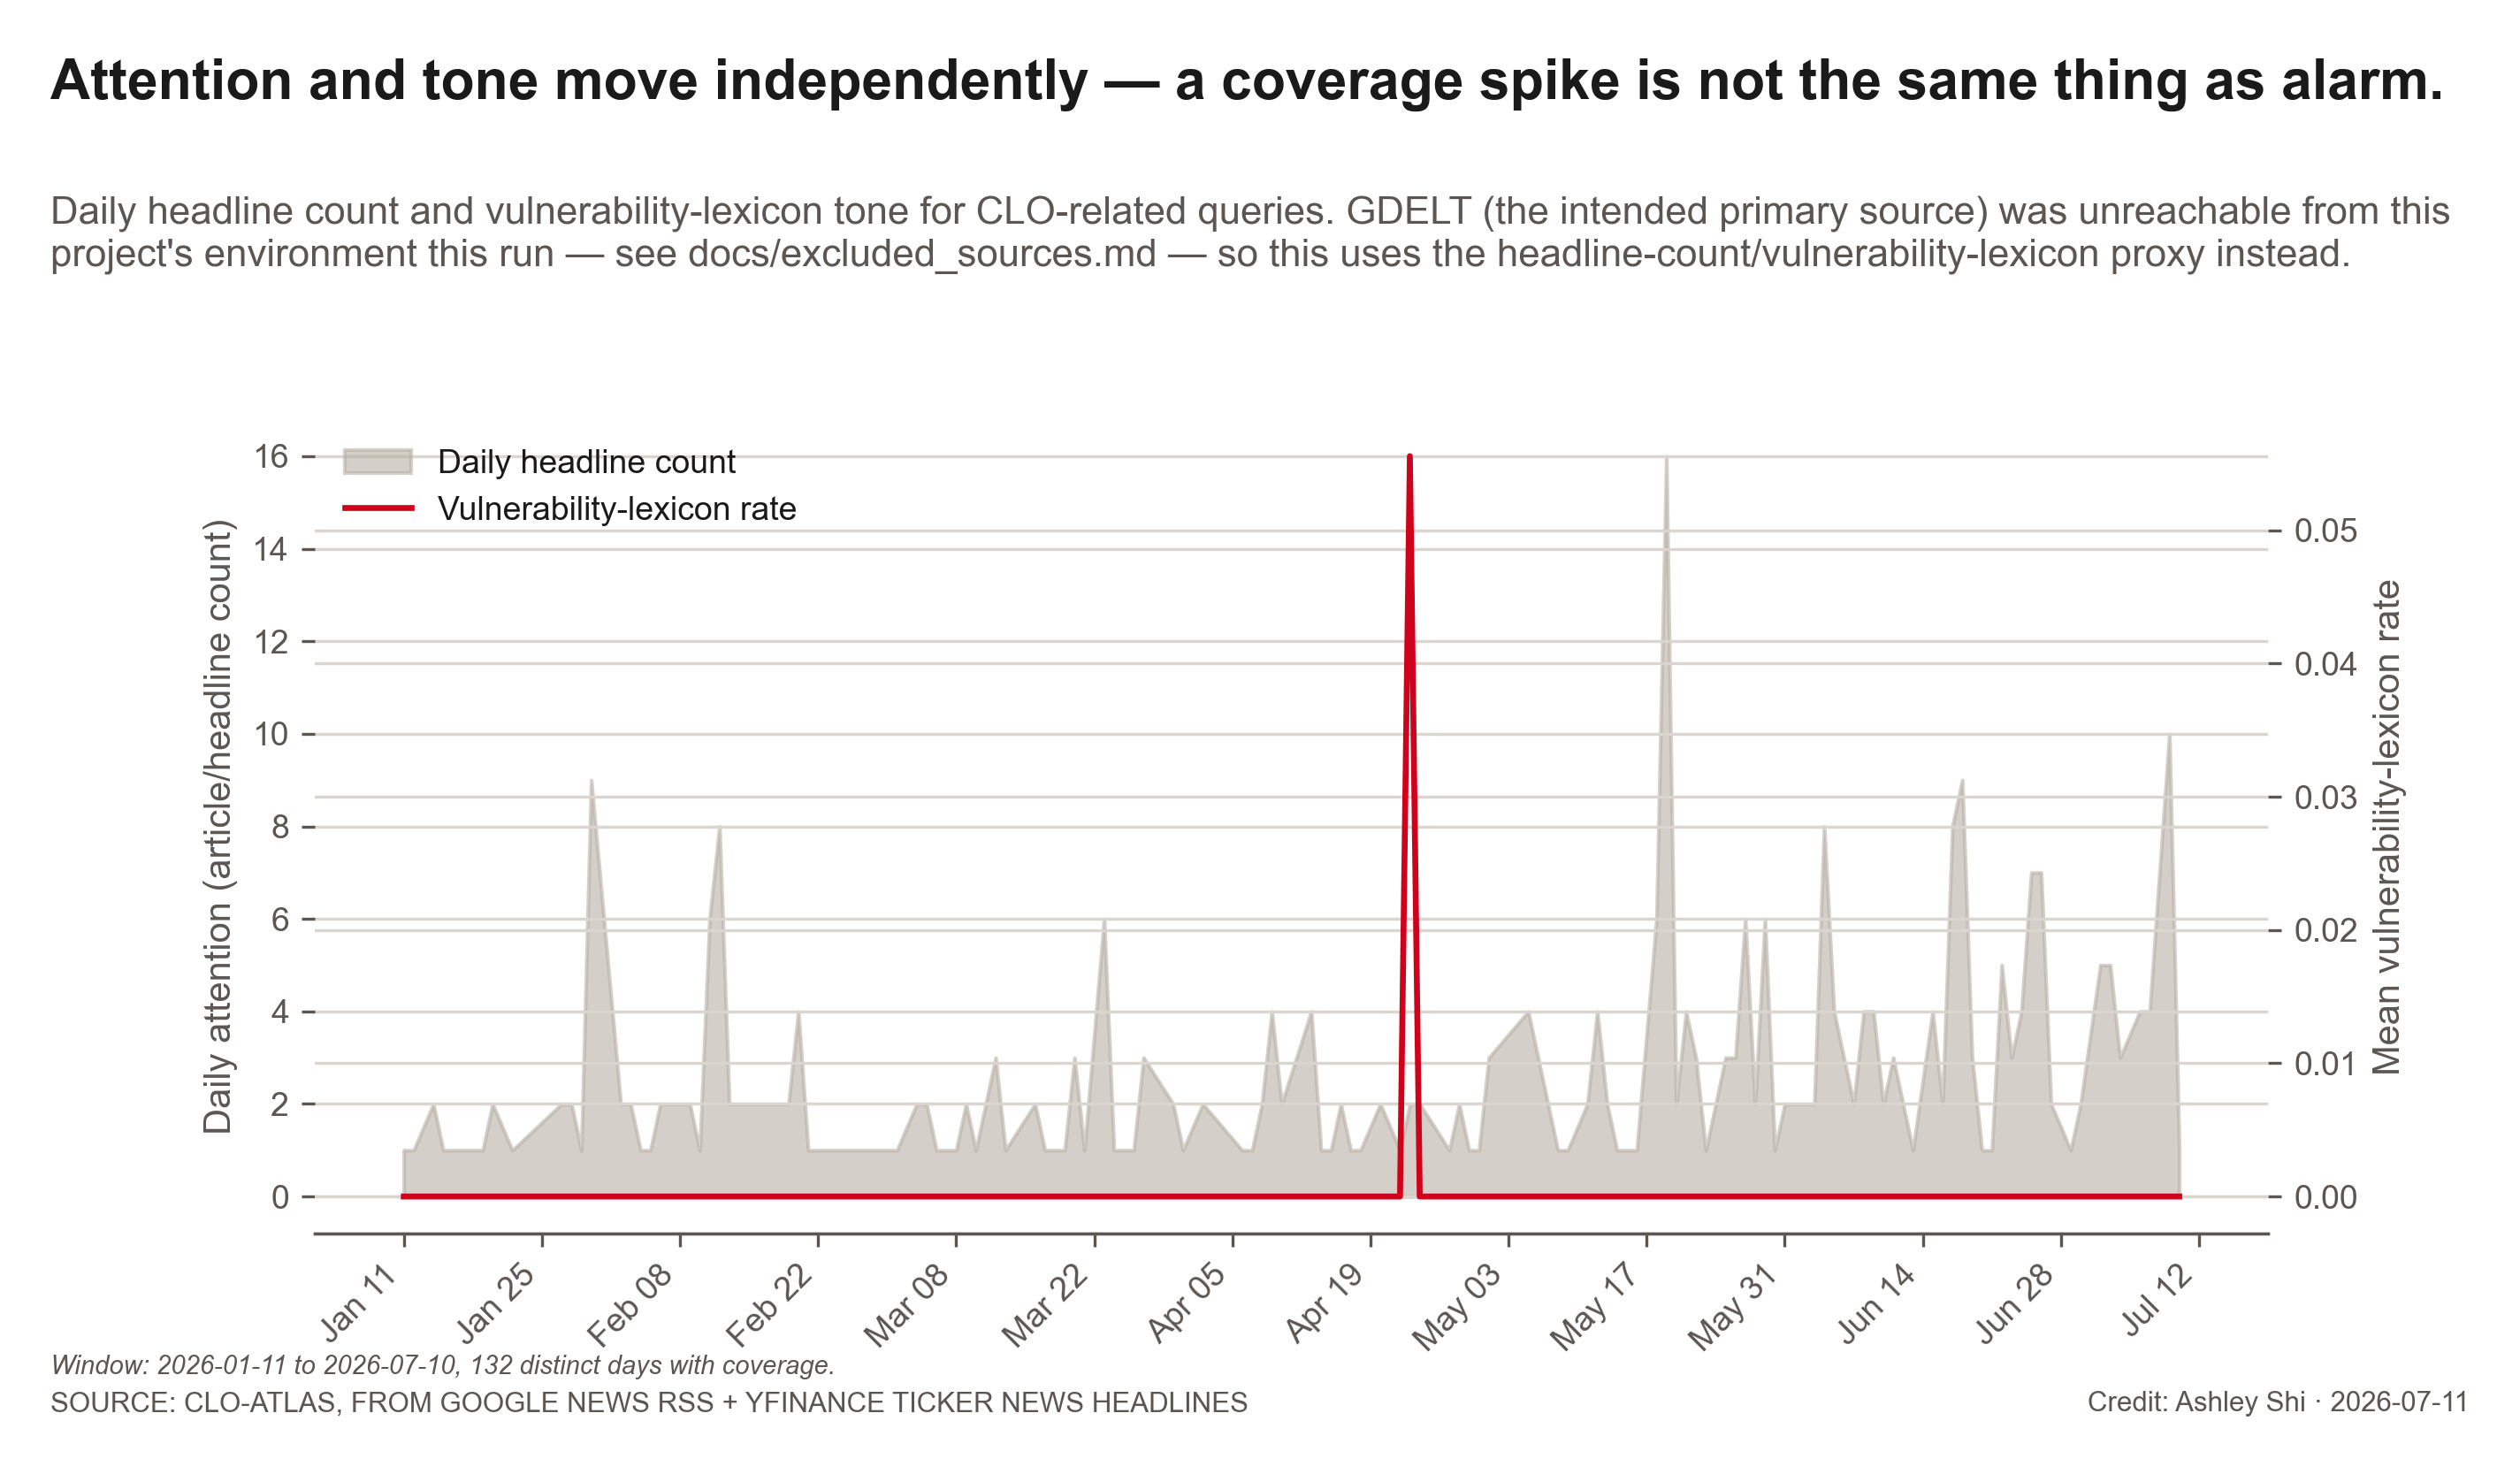

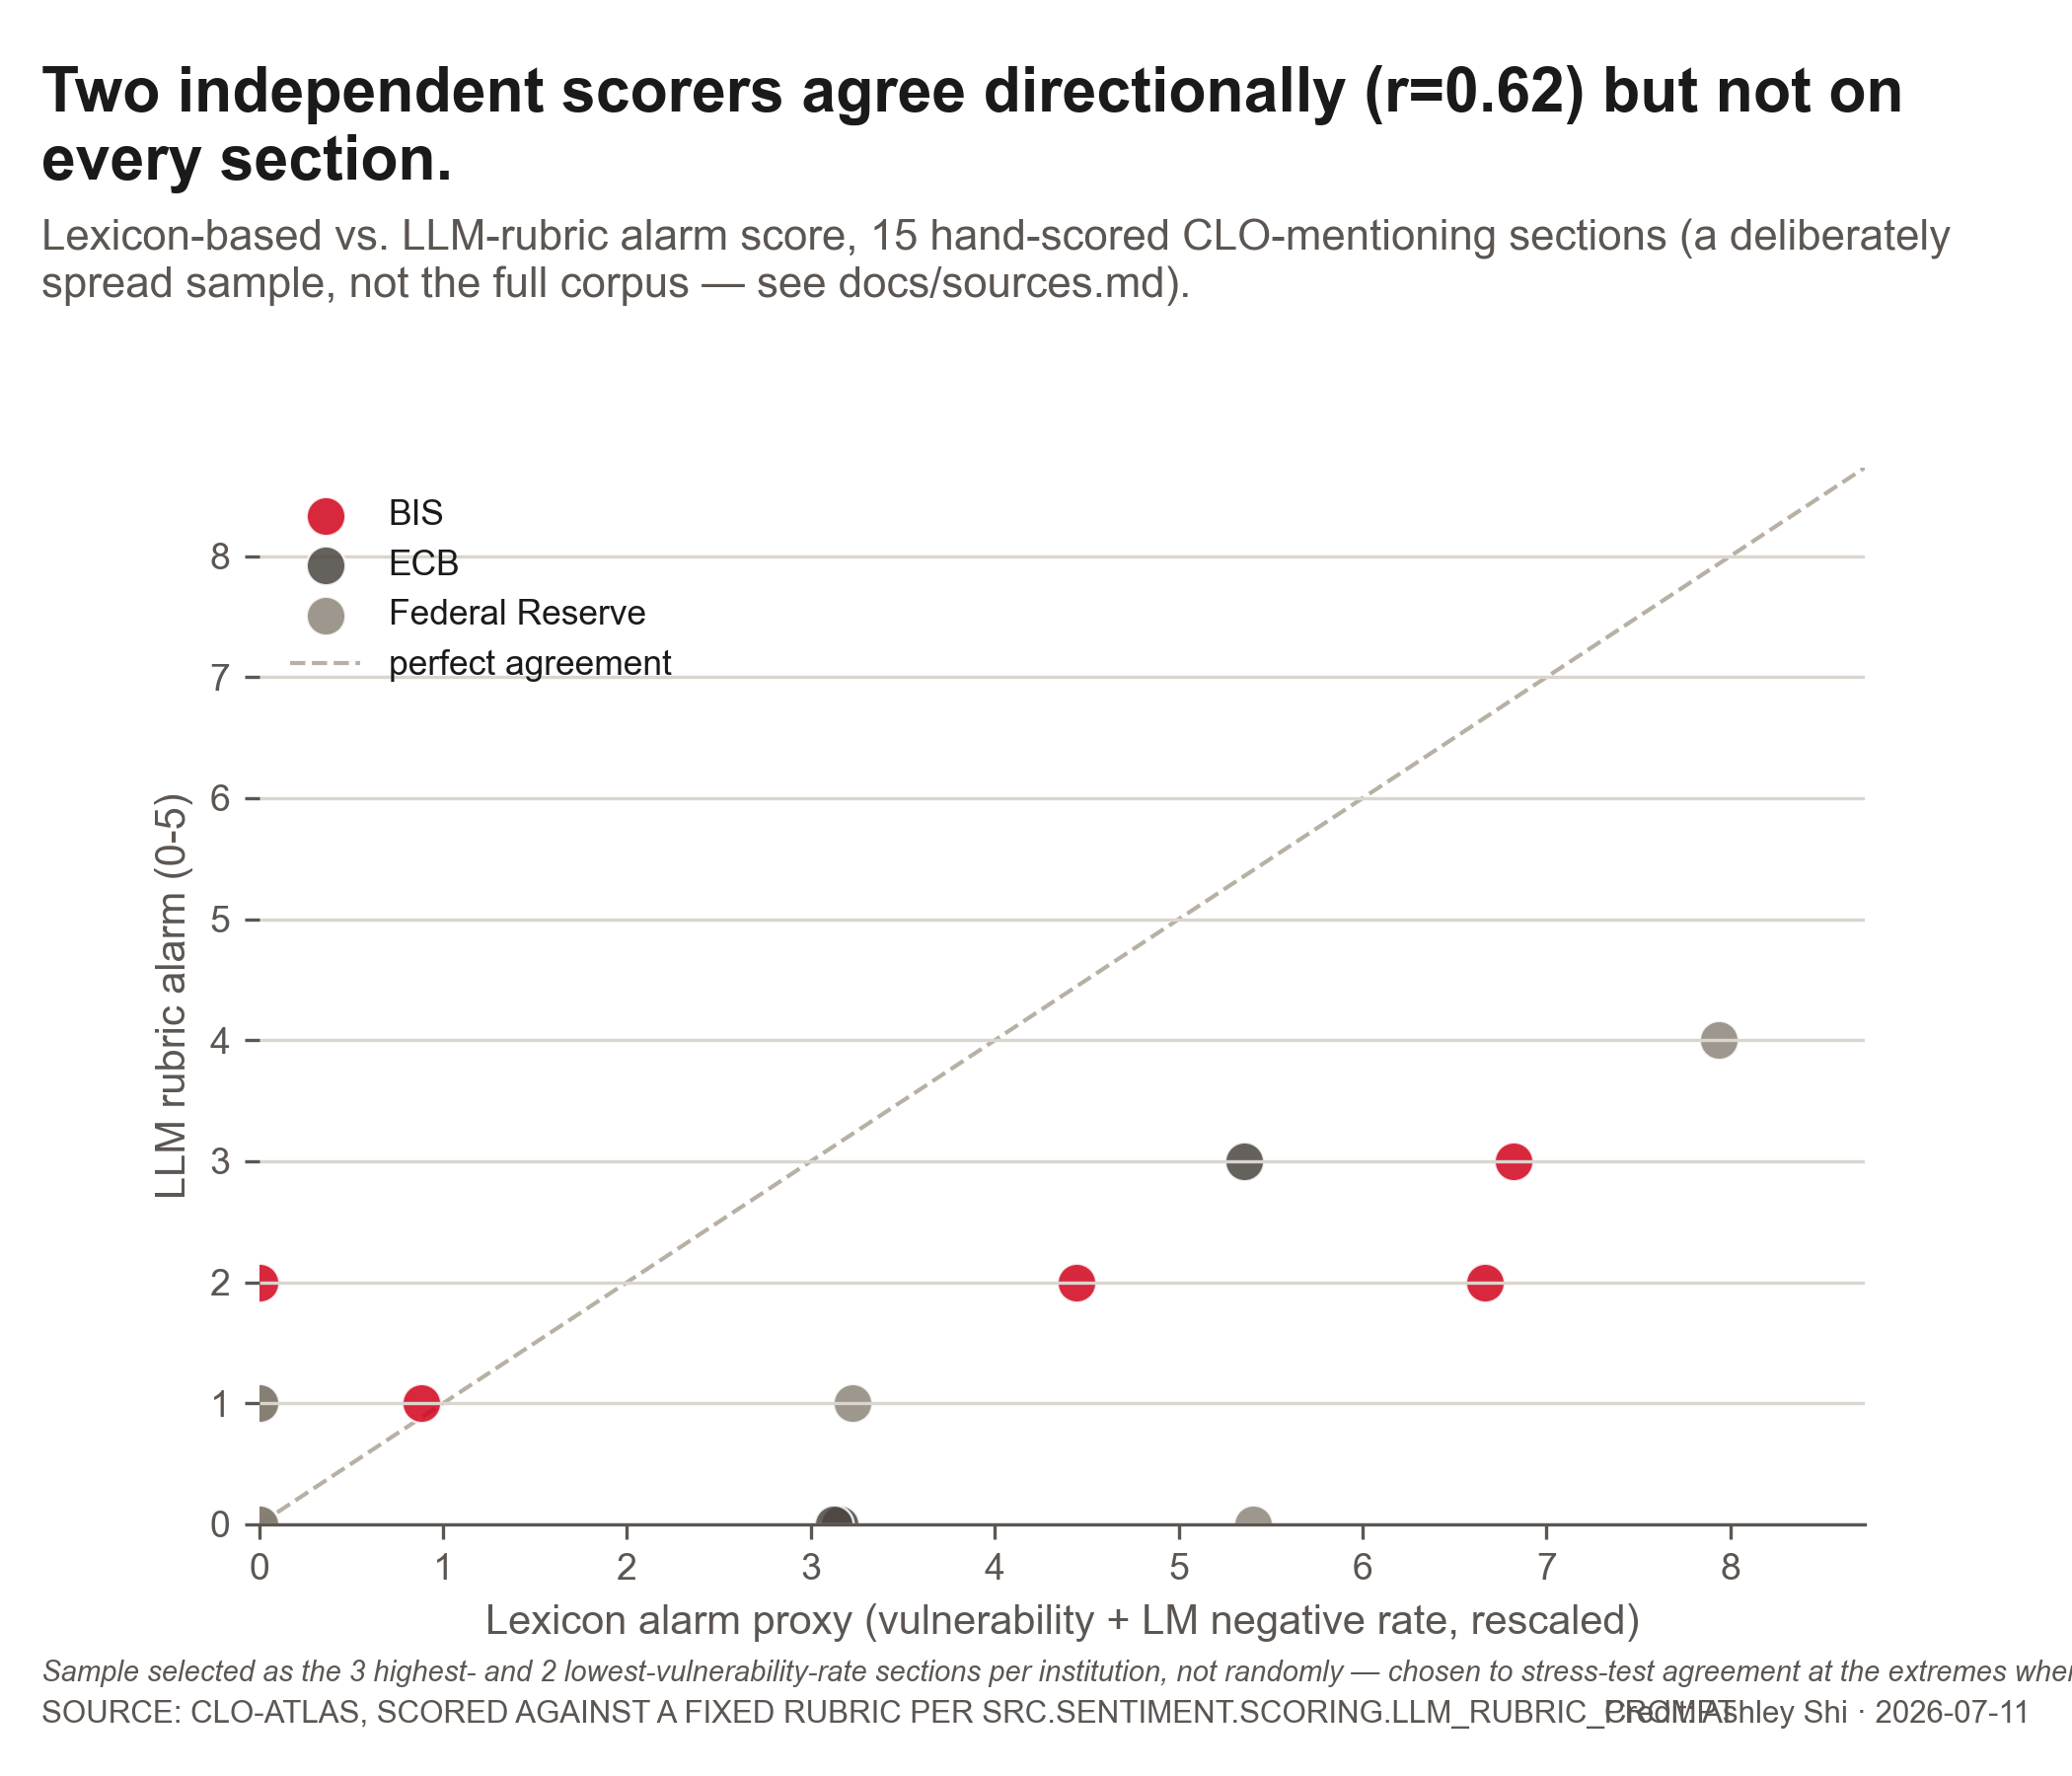

In [5]:
EXHIBITS = [
    "viz_alarm_index_small_multiples", "viz_alarm_components",
    "viz_attention_backbone",
    "viz_scorer_agreement",
]
for name in EXHIBITS:
    path = pathlib.Path("../figures") / f"{name}.png"
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print(f"[skipped — not generated this run] {name}")


## VERIFIED / TO-VERIFY ledger

Every number appearing in this section's exhibits, tagged `VERIFIED` (computed here) or `GAP` (a planned link/source that free data could not support, reported rather than dropped).

In [6]:
sentiment_v2_ledger = ledger.run()
sentiment_v2_ledger


,value,computation_or_citation,as_of,tag
0,66 regulator documents scored across 4 institu...,coverage_table(): document count by institutio...,n/a,VERIFIED
1,Additive alarm index has real variation across...,additive_alarm_index(): institution-z-scored m...,n/a,VERIFIED
2,"Highest-alarm report: BIS, 2022-09-28",alarm_index_v2 peak value in the rebuilt index,2022-09-28,VERIFIED
3,Lexicon-vs-LLM scorer correlation: r=0.62 on 1...,analysis_scorer_validation.py: hand-scored sam...,n/a,VERIFIED
4,GDELT attention/tone backbone: NOT AVAILABLE t...,Persistently rate-limited (429) from this proj...,n/a,GAP — degraded gracefully
5,455 headlines across 212 distinct days (news R...,analysis_attention_tone.headline_daily(),n/a,VERIFIED
6,2 CLO pricing announcements classified from th...,scrape_pressreleases.classify_pricing_announce...,n/a,VERIFIED
